(0.2, 0.3)

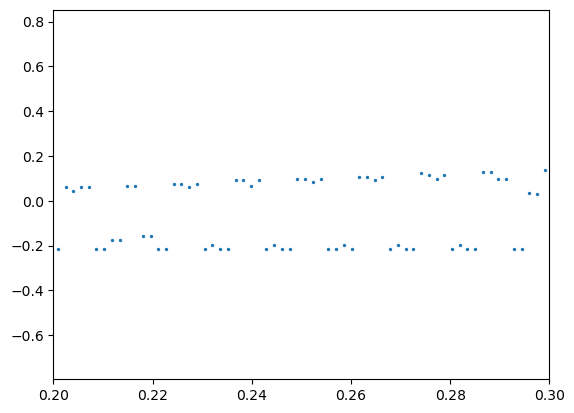

In [136]:
import numpy
import matplotlib.pyplot as plt
import pyvisa

def scope_read(channel_no):

    scope = pyvisa.ResourceManager().open_resource('USB0::0x1AB1::0x0515::MS5A255207443::INSTR')
    channel = str(channel_no)

    # scope.write("TIMebase:MAIN:SCALe 0.130")
    # scope.write(":CHANnel1:SCALe 2.")
    # scope.write(":CHANnel2:SCALe 0.2")
    # scope.write(":CHANnel3:SCALe 0.02")

    scope.write(":STOP")
    timescale = float(scope.query(":TIM:SCAL?"))
    timeoffset = float(scope.query(":TIM:OFFS?"))
    voltscale = float(scope.query(f':CHAN{channel}:SCAL?'))
    voltoffset = float(scope.query(f":CHAN{channel}:OFFS?"))
    scope.write(f":WAV:SOUR CHAN{channel}")
    scope.write(f":WAV:DATA? CHAN{channel}") #Request the data
    rawdata = scope.read_raw() #Read the block of data
    rawdata = rawdata[ 10 : ] #Drop the heading
    scope.write(":KEY:FORCE")
    scope.close()

    data = numpy.frombuffer(rawdata, 'B')
    data = (data - 128.0) * 10 * voltscale / 256 - voltoffset #update
    time = numpy.linspace(timeoffset - 6 * timescale, timeoffset + 6 * timescale, num=len(data))

    # See if we should use a different time axis
    if (time[-1] < 1e-3):
        time = time * 1e6
        tUnit = "uS"
    elif (time[-1] < 1):
        time = time * 1e3
        tUnit = "mS"
    else:
        tUnit = "S"

    # Plot the data
    # plt.plot(time, data)
    # plt.title(f"Oscilloscope Channel {channel}")
    # plt.ylabel("Voltage (V)")
    # plt.xlabel("Time (" + tUnit + ")")
    # plt.xlim(time[0], time[-1])
    # plt.show()
    return time, data, tUnit
t1, d1, tunit = scope_read(1)
#t2, d2, tunit = scope_read(2)
t3, d3, tunit = scope_read(3)
#plt.plot(t1,d1)
#plt.plot(t2,d2+.2)
#plt.plot(t3,d3)
#I = d3
plt.scatter(t2,d2,s = 2)
#plt.scatter(d2+0.2,d3,s=2)
plt.xlim(.2,.3)
#plt.xlim(.2,.25)
# plt.xlabel('Time ({})'.format(tunit))
# plt.ylabel("Current (A)")

c:\Users\pmlbl\OneDrive\Documents\PythonScripts\Notebooks


(2025.0, 2075.0)

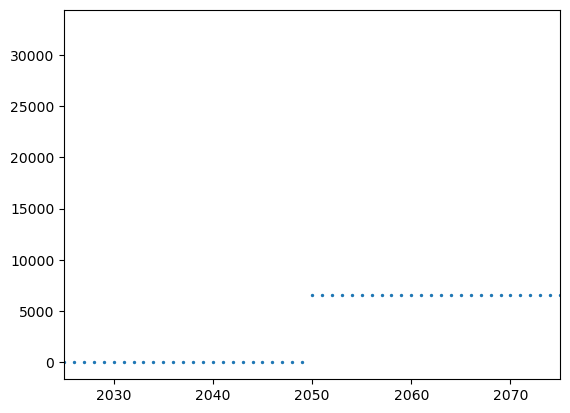

In [147]:
import AW_Gen

wf = AW_Gen.wf_settings(0,1,100,50)
AW_Gen.wf_settings.wf_generator(wf)
plt.scatter(range(len(wf.arry)),wf.arry,s=2)
plt.xlim(2025,2075)
